In [173]:
import pandas as pd
df = pd.read_csv("../../data/Heart.csv", index_col=0)
df.head()

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
1,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
2,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
3,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
4,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
5,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No


In [174]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 303 entries, 1 to 303
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        303 non-null    int64  
 1   Sex        303 non-null    int64  
 2   ChestPain  303 non-null    object 
 3   RestBP     303 non-null    int64  
 4   Chol       303 non-null    int64  
 5   Fbs        303 non-null    int64  
 6   RestECG    303 non-null    int64  
 7   MaxHR      303 non-null    int64  
 8   ExAng      303 non-null    int64  
 9   Oldpeak    303 non-null    float64
 10  Slope      303 non-null    int64  
 11  Ca         299 non-null    float64
 12  Thal       301 non-null    object 
 13  AHD        303 non-null    object 
dtypes: float64(2), int64(9), object(3)
memory usage: 35.5+ KB


In [175]:
df_no_nulls = df.dropna()
df_no_nulls.info()

<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 1 to 302
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        297 non-null    int64  
 1   Sex        297 non-null    int64  
 2   ChestPain  297 non-null    object 
 3   RestBP     297 non-null    int64  
 4   Chol       297 non-null    int64  
 5   Fbs        297 non-null    int64  
 6   RestECG    297 non-null    int64  
 7   MaxHR      297 non-null    int64  
 8   ExAng      297 non-null    int64  
 9   Oldpeak    297 non-null    float64
 10  Slope      297 non-null    int64  
 11  Ca         297 non-null    float64
 12  Thal       297 non-null    object 
 13  AHD        297 non-null    object 
dtypes: float64(2), int64(9), object(3)
memory usage: 34.8+ KB


In [176]:


df_no_nulls["AHD"].value_counts()

AHD
No     160
Yes    137
Name: count, dtype: int64

In [177]:
df_no_nulls

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
1,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
2,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
3,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
4,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
5,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,asymptomatic,140,241,0,0,123,1,0.2,2,0.0,reversable,Yes
299,45,1,typical,110,264,0,0,132,0,1.2,2,0.0,reversable,Yes
300,68,1,asymptomatic,144,193,1,0,141,0,3.4,2,2.0,reversable,Yes
301,57,1,asymptomatic,130,131,0,0,115,1,1.2,2,1.0,reversable,Yes


In [178]:
# dummies to convert categorical vals
df_dummies = pd.get_dummies(df_no_nulls, drop_first=True)
df_dummies.head()

,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,ChestPain_nonanginal,ChestPain_nontypical,ChestPain_typical,Thal_normal,Thal_reversable,AHD_Yes
1,63,1,145,233,1,2,150,0,2.3,3,0.0,False,False,True,False,False,False
2,67,1,160,286,0,2,108,1,1.5,2,3.0,False,False,False,True,False,True
3,67,1,120,229,0,2,129,1,2.6,2,2.0,False,False,False,False,True,True
4,37,1,130,250,0,0,187,0,3.5,3,0.0,True,False,False,True,False,False
5,41,0,130,204,0,2,172,0,1.4,1,0.0,False,True,False,True,False,False


In [179]:
X, y = df_dummies.drop("AHD_Yes", axis=1), df_dummies["AHD_Yes"]

In [180]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

X_train.shape, X_test.shape

((198, 16), (99, 16))

In [181]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

y_pred[:10]

array([False,  True, False,  True, False, False,  True,  True,  True,
       False])

In [182]:
y_test[:10].values

array([False,  True, False,  True, False, False, False, False,  True,
       False])

              precision    recall  f1-score   support

       False       0.82      0.85      0.83        53
        True       0.82      0.78      0.80        46

    accuracy                           0.82        99
   macro avg       0.82      0.82      0.82        99
weighted avg       0.82      0.82      0.82        99



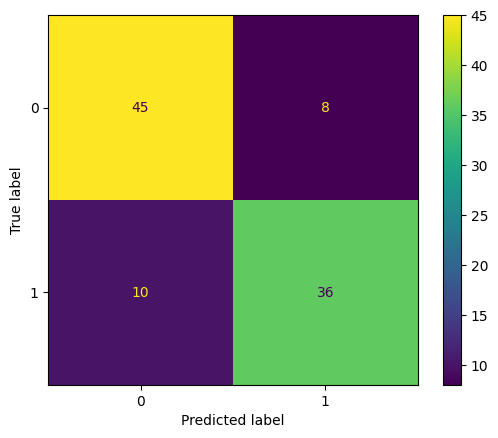

In [183]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot();

## feature importance


In [184]:
model.feature_importances_

array([0.09866444, 0.02791033, 0.06971357, 0.09790768, 0.01219051,
       0.021508  , 0.12101866, 0.03813781, 0.09392447, 0.02326788,
       0.14950017, 0.04838262, 0.00928418, 0.01955232, 0.0949987 ,
       0.07403867])

In [185]:
X.columns

Index(['Age', 'Sex', 'RestBP', 'Chol', 'Fbs', 'RestECG', 'MaxHR', 'ExAng',
       'Oldpeak', 'Slope', 'Ca', 'ChestPain_nonanginal',
       'ChestPain_nontypical', 'ChestPain_typical', 'Thal_normal',
       'Thal_reversable'],
      dtype='object')

In [186]:
len(X.columns), len(model.feature_importances_)

(16, 16)

In [187]:
feature_importance = pd.DataFrame([X.columns, model.feature_importances_])
feature_importance

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,ChestPain_nonanginal,ChestPain_nontypical,ChestPain_typical,Thal_normal,Thal_reversable
1,0.098664,0.02791,0.069714,0.097908,0.012191,0.021508,0.121019,0.038138,0.093924,0.023268,0.1495,0.048383,0.009284,0.019552,0.094999,0.074039


In [188]:
feature_importance = feature_importance.T
feature_importance.columns = ["Feature", "Importance"]
feature_importance

,Feature,Importance
0,Age,0.098664
1,Sex,0.02791
2,RestBP,0.069714
3,Chol,0.097908
4,Fbs,0.012191
5,RestECG,0.021508
6,MaxHR,0.121019
7,ExAng,0.038138
8,Oldpeak,0.093924
9,Slope,0.023268


In [189]:
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)
feature_importance


,Feature,Importance
10,Ca,0.1495
6,MaxHR,0.121019
0,Age,0.098664
3,Chol,0.097908
14,Thal_normal,0.094999
8,Oldpeak,0.093924
15,Thal_reversable,0.074039
2,RestBP,0.069714
11,ChestPain_nonanginal,0.048383
7,ExAng,0.038138


In [190]:
feature_importance["Importance"].sum()

np.float64(1.0000000000000002)

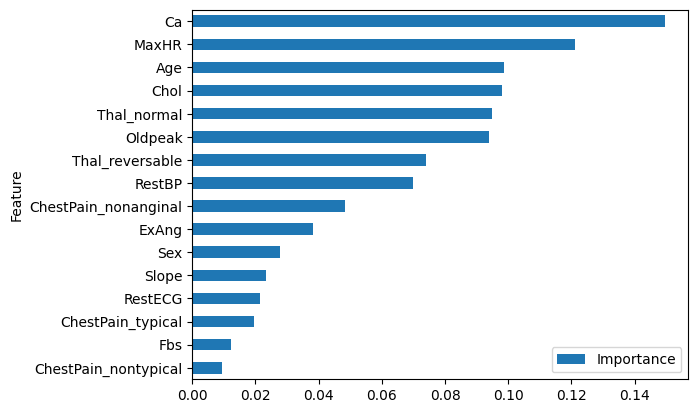

In [191]:
ax = feature_importance.plot(y="Importance", x="Feature", kind="barh")
ax.invert_yaxis()